# MACHINE LEARNING PROJECT

### Track T4 – Semi-Supervised Learning (SSL)
The objective of the project is to study and apply semi-supervised learning techniques to tabular data, analyzing how the limited availability of labels affects the performance of predictive models.

I'm interested in cybersecurity, so I chose the CSE-CIC-IDS2018 Intrusion CSVs (IDS 2018) dataset for the classification problem.

The dataset is based on logs from university servers, which recorded various DoS attacks during the publicly available period.
In total, there are eighty columns within this dataset, each of which corresponds to an entry in the IDS logging system that the Unversity of New Brunswick has in place.

Each entry in the dataset is originally labeled with multiple classes, such as Benign, FTP-BruteForce, and Other. To simplify the task and formulate it as a binary classification problem, I will consolidate all non-Benign labels into a single Malicious category. This way, the model will learn to distinguish between Benign and Malicious network traffic.

## Import libraries and models
I import the libraries and modules that we will need for the project.

In [1]:
import pandas as pd
import dask.dataframe as dd
from dask_ml.preprocessing import Categorizer
import matplotlib.pyplot as plt
import os

## Load and manipulate the dataset
I load the dataset using only a single large CSV instead of all the files.This simplifies processing, avoids mismatched type issues, and reduces memory usage.  
At the same time, I convert all labels that are not "Benign" into a single "Malicious" category.  
I use Dask that is a library which performs lazy loading to avoid loading the entire dataset into memory.

Label
Benign       7372557
Malicious     576191
Name: count, dtype: int64 



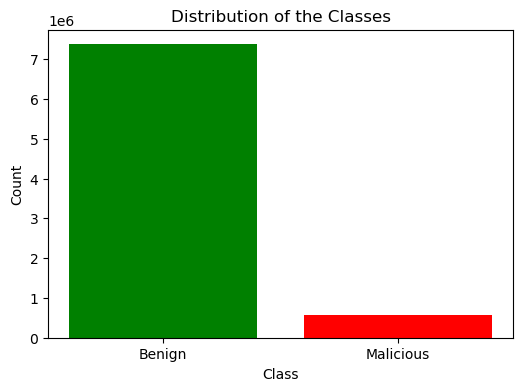

In [2]:
def showPlot(width, height, title, xDescription, yDescription, values, color):
    plt.figure(figsize=(width, height))
    plt.bar(values.index, values.values, color = color)
    plt.title(title)
    plt.xlabel(xDescription)
    plt.ylabel(yDescription)
    plt.show()

dataset = dd.read_csv("Dataset/02-20-2018.csv", assume_missing = True)
dataset["Label"] = dataset["Label"].map(lambda x: "Malicious" if x != "Benign" else "Benign")
counts = dataset["Label"].value_counts(dropna=False).compute()
print(counts,"\n")
showPlot(6, 4, "Distribution of the Classes", "Class", "Count", counts, ["green", "red"])

As I can see, all entries are labeled, but the dataset is strongly imbalanced toward benign samples.  
Now I check the entire dataset for entries with any missing feature values.

Entries that have at least 1 null feature value: 36767
Total Entries: 7948748
Percentage of dirty entries: 0.46%

Analyzing dirty entries:
 Label
Benign    36767
Name: count, dtype: int64 



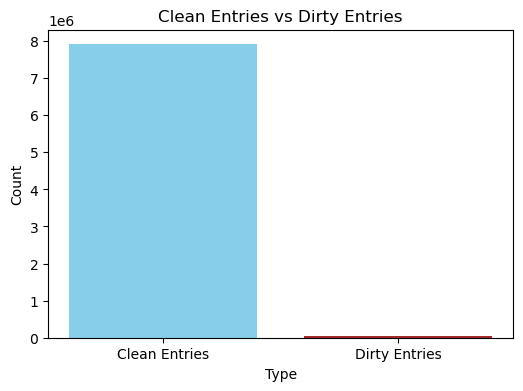

In [3]:
def printStats(showPlotFlag):
    dirty_entries_dt = dataset[dataset.isna().any(axis=1)]
    dirty_entries = dirty_entries_dt.shape[0].compute()
    total_entries = dataset.shape[0].compute()
    clean_entries = total_entries - dirty_entries
    print(f"Entries that have at least 1 null feature value: {dirty_entries}\nTotal Entries: {total_entries}\nPercentage of dirty entries: {dirty_entries / total_entries:.2%}\n")
    if(dirty_entries > 0):
        print("Analyzing dirty entries:\n" , dirty_entries_dt["Label"].value_counts().compute(), "\n")
    if(showPlotFlag):
        counts = pd.Series([clean_entries, dirty_entries], index = ["Clean Entries", "Dirty Entries"])
        showPlot(6, 4, "Clean Entries vs Dirty Entries", "Type", "Count", counts, ["skyblue", "brown"])
    
printStats(True)

At this point, we see that entries with missing values are less than 1% of the total dataset. Dropping features or filling missing values doesn’t make sense, since most of features are important in traffic analysis, and assigning values could introduce noise and break the real patterns. Therefore, I will remove these incomplete entries from the dataset. Moreover, as noted above, the dataset is heavily imbalanced towards Benign entries (there are many more of them), so removing the dirty entries, which are all Benign, is even more justified.

In [4]:
dataset = dataset.dropna()
printStats(False)

Entries that have at least 1 null feature value: 0
Total Entries: 7911981
Percentage of dirty entries: 0.00%



According to a statistical study conducted by Cloudflare, approximately 6.8% of Internet traffic comes from malicious activities. The dataset shows a percentage of malicious activity relative to benign activity of about 7.8%, so the data reflects real-world conditions. I could apply oversampling techniques, i.e., increasing the number of malicious entries, for example by duplicating them, but this may lead to overfitting. Alternatively, I could use undersampling techniques, reducing the number of benign entries at the cost of losing important information for the model. Since the goal of the project is to demonstrate the effectiveness of a semi-supervised learning approach, I will avoid balancing the dataset for now, but I will apply a model training technique that gives higher weight to malicious instances so that the model learns to predict both classes well, not just the benign ones.

## Features Cleaning
This dataset contains network traffic analysis data between devices and university servers, so it is necessary to carefully examine all the features available in each entry and remove those that are not relevant for analyzing future network traffic and making predictions, thereby essentially avoiding model overfitting.

In [5]:
print(dataset.columns, "\n\nNumber of features: ", dataset.shape[1])

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

Among all these features, we can remove the <span style="color:red"><b>Flow ID</b></span>, which is unique and therefore carries no weight in the learning process. The <span style="color:red"><b>destination IP</b></span> is not relevant because it only indicates which university server the packets are sent to and does not help distinguish malicious from benign traffic. Similarly, the <span style="color:red"><b>source IP</b></span> is not useful, as it could be spoofed and, like the destination IP, does not aid in discrimination; in fact, it can cause overfitting—if the model learns that a specific IP is benign, it will continue to trust it blindly, which is very dangerous. The <span style="color:red"><b>source port</b></span> is also not important, since it is often random and, being frequently unknown, analyzing it usually makes little sense. On the other hand, the destination port could be useful because malicious attacks often target well-known ports, such as those for DNS, email services, or Sony services, so analyzing it can contribute to traffic analysis and model learning. The <span style="color:red"><b>timestamp</b></span> could be useful in a time series study, but in our case, we remove it because it does not provide any relevant information.

In [6]:
dataset = dataset.drop(["Flow ID", "Src IP", "Src Port", "Dst IP", "Timestamp"], axis=1)
print(dataset.columns, "\n\nNumber of features: ", dataset.shape[1])

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Siz

The dataset indicates that the most important attributes are <span style="color:green"><b>Dst Port</b></span>, <span style="color:green"><b>Protocol</b></span>, <span style="color:green"><b>Flow Duration</b></span>, <span style="color:green"><b>Tot Fwd Pkts</b></span>, <span style="color:green"><b>Tot Bwd Pkts</b></span>. Therefore, during learning, we will give greater weight to these features to improve model performance.

## Handling Text and Categorical Attributes
Before training the model, all categorical and textual features are transformed into numerical representations to ensure compatibility with the learning algorithms.

In [7]:
print(dataset.dtypes)

Dst Port         float64
Protocol         float64
Flow Duration    float64
Tot Fwd Pkts     float64
Tot Bwd Pkts     float64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max         float64
Idle Min         float64
Label             object
Length: 79, dtype: object


The Label column is the only categorical feature in the dataset and therefore must be transformed into a numerical representation before training the model.  
Since the Label column contains only two categories, I can use a Categorical Encoder of Dask to convert them into numerical values, assigning 0 to BENIGN and 1 to MALICIOUS.

In [8]:
cat_enc = Categorizer(columns=["Label"])
dataset = cat_enc.fit_transform(dataset)
dataset["Label"] = dataset["Label"].cat.codes
print(dataset.dtypes,"\n")
print(dataset["Label"].value_counts(dropna=False).compute())

Dst Port         float64
Protocol         float64
Flow Duration    float64
Tot Fwd Pkts     float64
Tot Bwd Pkts     float64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max         float64
Idle Min         float64
Label               int8
Length: 79, dtype: object 

Label
0    7335790
1     576191
Name: count, dtype: int64


## Create Training Set and Test set
Now we randomly split the dataset. As we know, the training set is used to train the models, while the test set is used to assess the final performance on unseen data. The random_state parameter, as the name suggests, is used to initialize the internal random number generator, which determines how the data is split into training and test sets. According to the documentation, setting a random_state ensures that the split is reproducible. The validation set will be considered at a later stage.  

Since the dataset is managed using Dask, which processes data in chunks rather than loading it entirely into memory, I implemented a custom stratified split of the dataset. This choice was necessary because the library does not provide a built-in API comparable to that of scikit-learn for performing such operations.

In a simple yet effective way, the two classes were first separated into two different files. Then, for each file—each containing only one class—80% of the data was assigned to the training set and the remaining 20% to the test set. This approach preserves the class distribution across the splits, which helps improve the quality and reliability of the model training.  

I simulate a semi-supervised scenario in which 93% of the labels are unavailable in the training set; therefore, we create an additional copy of the training set where most of the labels have been removed (i.e., masked), while keeping only a small labeled subset. 

The supervised baseline is trained exclusively on the small labeled subset (7%), while the semi-supervised approach leverages both the labeled data and the remaining unlabeled portion (93%), enabling a fair comparison of their effectiveness under limited labeling conditions. It's applied the same previous approach so that preserves the class distribution across the splits



Only_labeled:
Label
Benign       410612
Malicious     32418
Unlabeled         0
Name: count, dtype: int32
Malicious/Benign: 7.90%



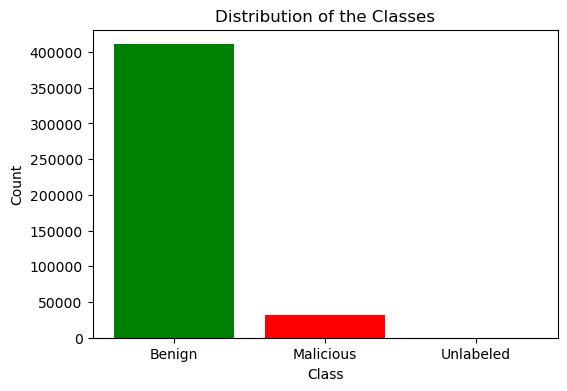

Semi_labeled:
Label
Benign        410612
Malicious      32418
Unlabeled    5886870
Name: count, dtype: int32
Malicious/Benign: 7.90%



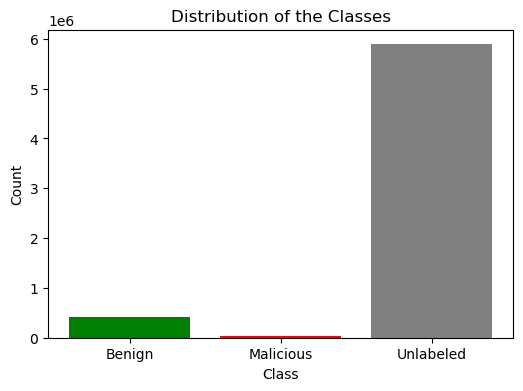

Test:
Label
Benign       1466634
Malicious     115447
Unlabeled          0
Name: count, dtype: int32
Malicious/Benign: 7.87%



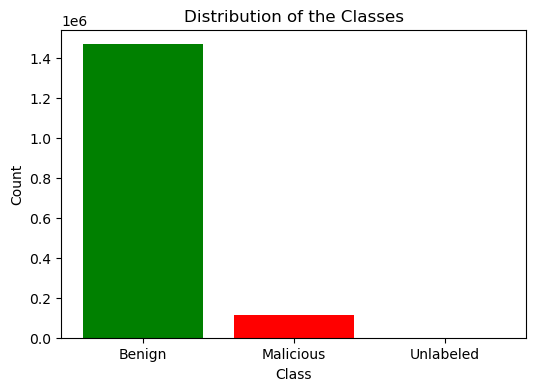

In [9]:
def saveData(dataset, path):
    dataset.to_csv(path, index=False, single_file=True)

def divideDataset(dataset):
    benign = dataset[dataset["Label"] == 0]
    malicious = dataset[dataset["Label"] == 1]
    saveData(benign, "Dataset/benign_classes.csv")
    saveData(malicious, "Dataset/malicious_classes.csv")

def createTrainAndTestSet(dataset_class1, dataset_class2):
    fractions = [0.8, 0.2]
    fractions2 = [0.93, 0.07]
    random_state = 7
    train_set1, test_set1 = dataset_class1.random_split(fractions, random_state=random_state)
    train_set2, test_set2 = dataset_class2.random_split(fractions, random_state=random_state)
    train_set1_unlabeled, train_set1_labeled = train_set1.random_split(fractions2, random_state=random_state)
    train_set2_unlabeled, train_set2_labeled = train_set2.random_split(fractions2, random_state=random_state)
    train_set1_unlabeled["Label"] = -1
    train_set2_unlabeled["Label"] = -1
    train_set_only_labeled = dd.concat([train_set1_labeled, train_set2_labeled]) 
    train_set_only_labeled_shuffled = train_set_only_labeled.sample(frac=1, random_state=random_state)  #trick to shuffle in Dask
    train_set_semi_labeled = dd.concat([train_set1_labeled, train_set2_labeled, train_set1_unlabeled, train_set2_unlabeled])
    train_set_semi_labeled_shuffled = train_set_semi_labeled.sample(frac=1, random_state=random_state)  #trick to shuffle in Dask
    saveData(train_set_only_labeled_shuffled, "Dataset/train_set_only_labeled.csv")
    saveData(train_set_semi_labeled_shuffled, "Dataset/train_set_semi_labeled.csv")
    saveData(dd.concat([test_set1, test_set2]), "Dataset/test_set.csv")
    
def stratified_train_test_split(dataset):
    if not (os.path.isfile("Dataset/train_set_only_labeled.csv") and os.path.isfile("Dataset/train_set_semi_labeled.csv") and os.path.isfile("Dataset/test_set.csv")):
        divideDataset(dataset)
        benign = dd.read_csv("Dataset/benign_classes.csv")
        malicious = dd.read_csv("Dataset/malicious_classes.csv")
        createTrainAndTestSet(benign, malicious)
    train_set_only_labeled = dd.read_csv("Dataset/train_set_only_labeled.csv", dtype={"Label": "object"})   
    train_set_semy_labeled = dd.read_csv("Dataset/train_set_semi_labeled.csv", dtype={"Label": "object"})   
    test_set = dd.read_csv("Dataset/test_set.csv", dtype={"Label": "object"})    
    return train_set_only_labeled, train_set_semy_labeled, test_set

train_set_only_labeled, train_set_semi_labeled, test_set = stratified_train_test_split(dataset)
datasets = [("Only_labeled", train_set_only_labeled), ("Semi_labeled", train_set_semi_labeled), ("Test", test_set)]
print("\n")
for name, dataset in datasets:
    counts = dataset["Label"].value_counts(dropna=False).compute()
    counts = counts.rename(index={'0': "Benign", '1': "Malicious", '-1': "Unlabeled"})
    counts = counts.reindex(["Benign", "Malicious", "Unlabeled"])
    counts = counts.fillna(0)
    counts = counts.astype(int)
    print(f"{name}:")
    print(f"{counts}\nMalicious/Benign: {counts.get('Malicious', 0) / counts.get('Benign', 0):.2%}\n")
    showPlot(6, 4, "Distribution of the Classes", "Class", "Count", counts, ['green', 'red', 'grey'])

As I see, these datasets were split correctly.   
Now I prepare the Data for Machine Learning Algorithms

In [10]:
x_train_only_labeled = train_set_only_labeled.drop("Label", axis=1)
y_train_only_labeled = train_set_only_labeled["Label"].copy()

x_train_semi_labeled = train_set_semi_labeled.drop("Label", axis=1)
y_train_semi_labeled = train_set_semi_labeled["Label"].copy()

x_test = test_set.drop("Label", axis=1)
y_test = test_set["Label"].copy()


## Semi-Supervised learning approaches
Within the context of semi-supervised learning, several approaches have been proposed to effectively exploit unlabeled data alongside a limited set of labeled examples. One widely used technique is self-training, a wrapper-based method in which a model is initially trained on labeled data and then iteratively assigns pseudo-labels to unlabeled instances based on high-confidence predictions. These newly labeled samples are subsequently incorporated into the training set, allowing the model to progressively refine its performance.

In addition, graph-based methods such as Label Propagation and Label Spreading provide an alternative perspective. In these approaches, data points are represented as nodes within a graph, where edges encode similarities between instances. Label Propagation directly spreads label information across the graph structure, whereas Label Spreading introduces a regularization mechanism that improves robustness, particularly in the presence of noisy data.

Overall, these methods aim to leverage the underlying structure of the data distribution in order to enhance classification performance, especially in scenarios where labeled data is scarce.  
## Choice of the model and the approaches
As the classification model, I employ Random Forests, an ensemble method based on decision trees that leverages the bagging technique. This model is chosen due to its strong performance across a wide range of scenarios. Moreover, it allows avoiding the need for a separate validation set, as the out-of-bag (OOB) error can be directly used to evaluate the model during training.

For completeness, the project also presents a comparison between a model trained using only 7% of the labeled data and models that additionally exploit the remaining 93% of unlabeled data. In particular, the latter are trained using three semi-supervised approaches: self-training, label propagation, and label spreading.